In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.ticker as mticker
import contextily as ctx

In [13]:
FullAdvan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv')

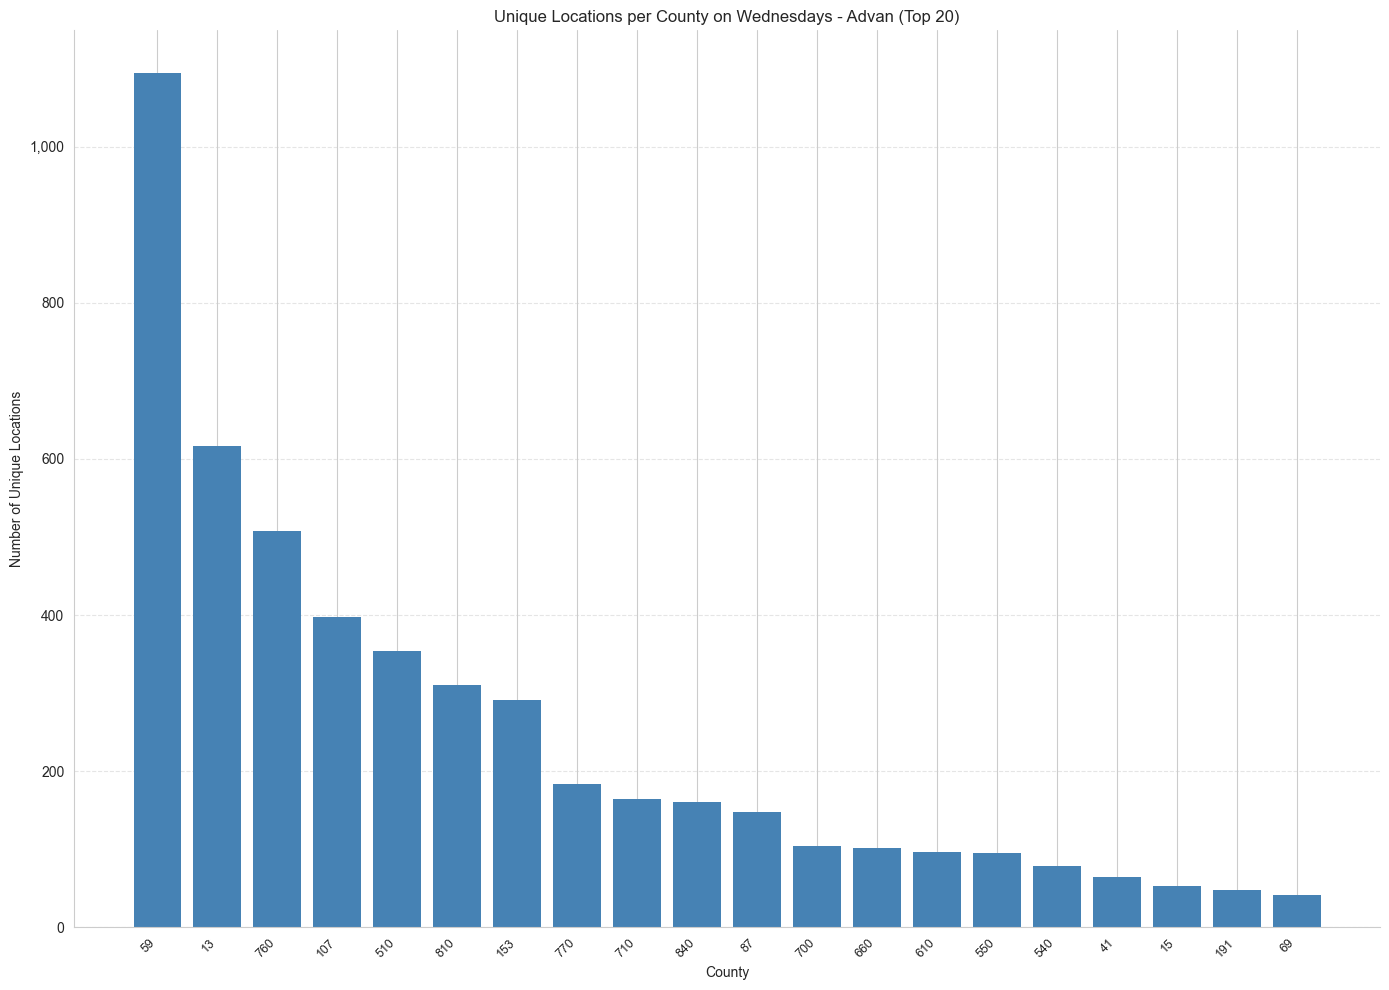

In [22]:
Ltop20 = (FullAdvan[FullAdvan['Wed'] > 0]
          .groupby('county')['placekey']
          .nunique()
          .sort_values(ascending=False)
          .head(20))

fig, ax = plt.subplots(figsize=(14, 10))
ax.bar(range(len(Ltop20)), Ltop20.values, color='steelblue', edgecolor='none')
ax.set_xticks(range(len(Ltop20)))
ax.set_xticklabels(Ltop20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('County')
ax.set_title('Unique Locations per County on Wednesdays - Advan (Top 20)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

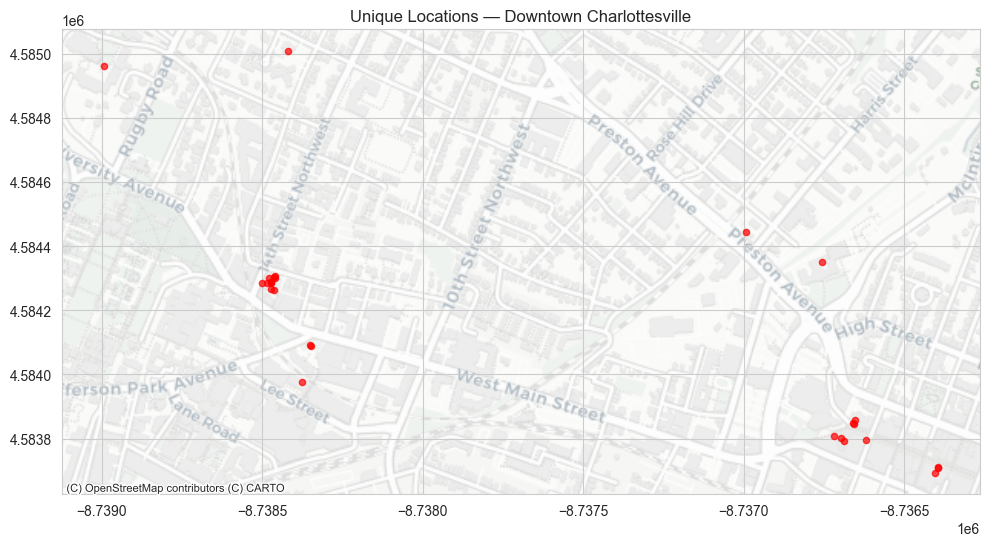

In [17]:
lat_min, lat_max = 38.025, 38.045
lon_min, lon_max = -78.510, -78.480

downtown = FullAdvan[
    (FullAdvan['latitude'].between(lat_min, lat_max)) &
    (FullAdvan['longitude'].between(lon_min, lon_max)) &
    (FullAdvan['Wed'] > 0)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

gdf = gpd.GeoDataFrame(downtown, geometry=gpd.points_from_xy(downtown['longitude'], downtown['latitude']), crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title('Unique Locations — Downtown Charlottesville')
plt.tight_layout()
plt.show()

Unique Advan locations in DC Metro: 708


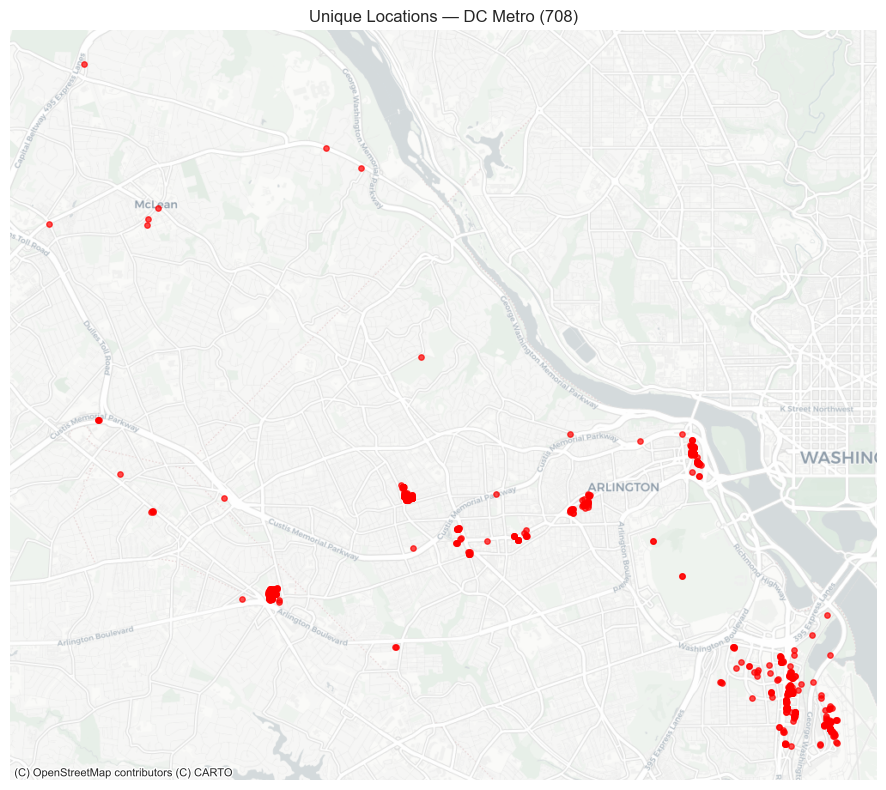

In [20]:
dc = FullAdvan[
    (FullAdvan['latitude'].between(38.85, 39.00)) &
    (FullAdvan['longitude'].between(-77.20, -76.95)) &
    (FullAdvan['Wed'] > 0)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in DC Metro: {len(dc)}")

gdf_dc = gpd.GeoDataFrame(dc, geometry=gpd.points_from_xy(dc['longitude'], dc['latitude']),
                           crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_dc.plot(ax=ax, color='red', markersize=15, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — DC Metro ({len(dc)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Richmond: 517


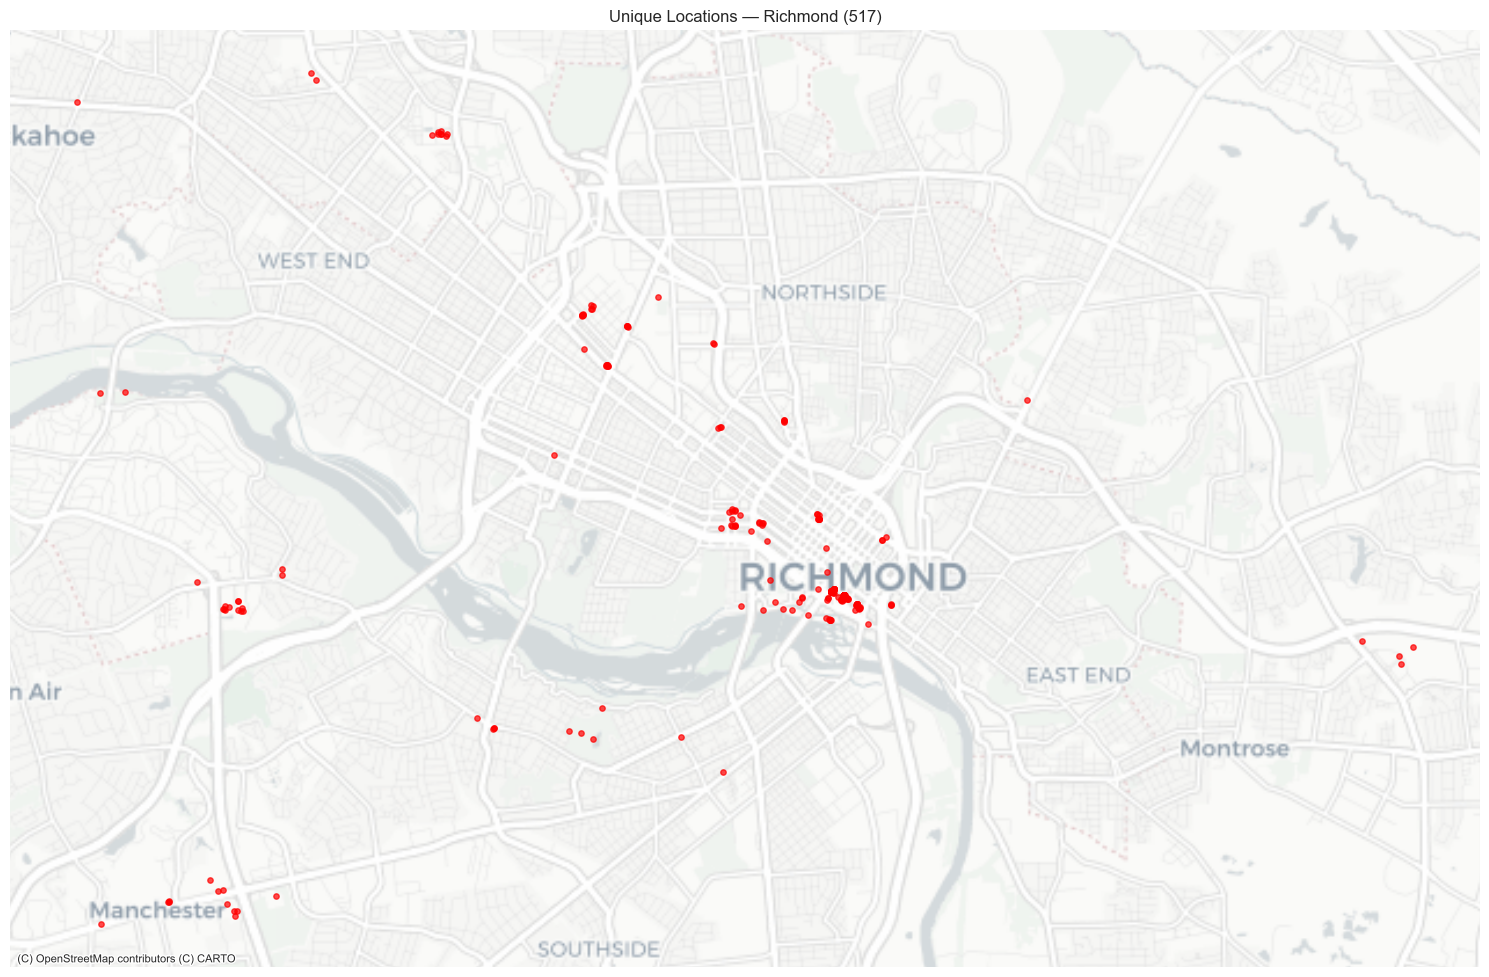

In [21]:
richmond = FullAdvan[
    (FullAdvan['latitude'].between(37.49, 37.60)) &
    (FullAdvan['longitude'].between(-77.55, -77.35)) &
    (FullAdvan['Wed'] > 0)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in Richmond: {len(richmond)}")

gdf_richmond = gpd.GeoDataFrame(richmond, geometry=gpd.points_from_xy(richmond['longitude'], richmond['latitude']),
                                 crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 15))
gdf_richmond.plot(ax=ax, color='red', markersize=15, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Richmond ({len(richmond)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()